In [32]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['JAX_PLATFORMS']='cpu'

import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state
import jax.random as random
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from jax.nn import initializers

def generate_nonuniform_dataset(n: int = 1000):
    # i) 10000 evenly-spaced points in the range [-pi, pi]
    large_dataset = jnp.linspace(-jnp.pi, jnp.pi, 10000)

    # ii) Select 20 points that minimize |sin(x) - sin(6x)|
    diff1 = jnp.abs(jnp.sin(large_dataset) - jnp.sin(6 * large_dataset))
    indices1 = jnp.argsort(diff1)[:20]
    selected_points1 = large_dataset[indices1]

    # Create a boolean mask to exclude the already selected points
    mask = jnp.ones(large_dataset.shape, dtype=bool)
    mask = mask.at[indices1].set(False)
    remaining_dataset = large_dataset[mask]

    # Calculate the differences for the remaining dataset
    diff2_remaining = jnp.abs(jnp.sin(2 * remaining_dataset) - jnp.sin(6 * remaining_dataset))
    indices2_remaining = jnp.argsort(diff2_remaining)[:10]
    selected_points2 = remaining_dataset[indices2_remaining]

    # iii) Combine these 30 points with n - 30 uniformly selected points
    num_uniform = n - 30
    uniform_points = jnp.linspace(-jnp.pi, jnp.pi, num_uniform)
    training_data = jnp.sort(
        jnp.concatenate([selected_points1, selected_points2, uniform_points])
    )
    return training_data
    
def generate_uniform_dataset(n: int = 1000):
    return jnp.linspace(-jnp.pi, jnp.pi, n)

def generate_test_dataset():
    return jnp.linspace(-jnp.pi, jnp.pi, 1000)

nonuniform_train_data = generate_nonuniform_dataset(65)
test_data = generate_test_dataset()

nonuniform_train_data = nonuniform_train_data.reshape((-1, 1))
test_data = test_data.reshape((-1, 1))
print(f"Nonuniform training data shape: {nonuniform_train_data.shape}")
# print(f"Uniform training data shape: {uniform_train_data.shape}")
# print(f"Test data shape: {test_data.shape}")

Nonuniform training data shape: (65, 1)


In [33]:
# The NN architecture employs a fully-connected structure with four hidden
# layers of widths 200-200-200-100. 
class Net(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=200,
                      kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(1), maxval=1 / jnp.sqrt(1)),
                      bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(1), maxval=1 / jnp.sqrt(1))
                     )(x)
        x = jnp.sin(x)
        x = nn.Dense(features=200,
                    kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                      bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                     )(x)
        x = jnp.sin(x)
        x = nn.Dense(features=200,
                    kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                      bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)))(x)
        x = jnp.sin(x)
        x = nn.Dense(features=100,
                     kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                      bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)))(x)
        x = jnp.sin(x)
        x = nn.Dense(features=1,
                    kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(100), maxval=1 / jnp.sqrt(100)),
                      bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(100), maxval=1 / jnp.sqrt(100)))(x)
        return x

In [34]:
# Define the loss function
def mse_loss(params, model, x, y):
    y_pred = model.apply({'params': params}, x)
    return jnp.mean((y_pred - y)**2)

# Create a training state
class TrainState(train_state.TrainState):
    pass

def create_train_state(module, rng, learning_rate):
    """Creates initial `TrainState`."""
    params = module.init(rng, jnp.zeros([1]))['params']
    optimizer = optax.adam(learning_rate)
    return TrainState.create(apply_fn=module.apply, params=params, tx=optimizer)

In [35]:
key = random.PRNGKey(1)
model = Net()
state = create_train_state(model, key, 2e-6)
num_train = nonuniform_train_data.shape[0]

In [36]:
# Define the training step
@jax.jit
def train_step(state, x_batch, y_batch, x_test, y_test):
    """Performs a single training step."""
    loss_fn = lambda params: mse_loss(params, Net(), x_batch, y_batch)
    grad_fn = jax.value_and_grad(loss_fn)
    loss, grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    
    loss_fn = lambda params: mse_loss(params, Net(), x_test, y_test)
    test_loss = loss_fn(state.params)
    return state, loss, test_loss

train_data_y = jnp.sin(6 * nonuniform_train_data)
test_data_y = jnp.sin(6 * test_data)
train_loss = []
test_loss = []
for iter in tqdm(range(20000)):
    state, loss, tloss = train_step(state, nonuniform_train_data, train_data_y, test_data, test_data_y)
    test_loss.append(tloss)
    train_loss.append(loss)

  0%|          | 0/20000 [00:00<?, ?it/s]

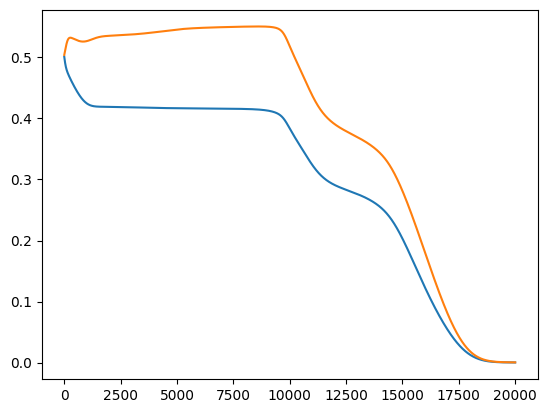

In [42]:
plt.plot(train_loss)
plt.plot(test_loss)
# plt.ylim((0, .7))

In [45]:
jnp.sin(- 6 *  jnp.pi)

Array(-4.7699523e-08, dtype=float32, weak_type=True)